# Machine Learning Modeling 

## Import Libraries

In [1]:
# import general python packages 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

# import classfier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# import model selection and preprocessing tools 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, f1_score


## Import Data 

In [2]:
X_train = pd.read_csv("data/X_train.csv", sep=",", low_memory= False) 
X_test = pd.read_csv("data/X_test.csv", sep=",", low_memory=False)

y_train = pd.read_csv("data/y_train.csv", sep=",", low_memory=False) 
y_test = pd.read_csv("data/y_test.csv", sep=",", low_memory=False) 

# Check lengths 
print(f"X: {len(X_train)}, y: {len(y_train)}")

X: 1524, y: 1524


## Define the Datasets

- **Dataset 1:** Full feature set. Remove rows with missing values in Polyphen_Score and SIFT_Score.
- **Dataset 2:** Exlude the features 'Polyphen_Score','SIFT_Score' 'missing_Polyphen', 'missing_SIFT'. 
- **Dataset 3:** Exclude the feature 'Consequence'. Remove missing values in 'Polyphen_Score' and 'SIFT_Score'.
- **Dataset 4:** Exclude the features 'Polyphen_Score', 'SIFT_Score', 'missing_Polyphen', 'missing_SIFT', 'Consequence'.
- **Dataset 5:** Full feature set. Impute -1 in rows with missing Polyphen and SIFT scores. 

## Create Datasets

### Define columns to handle

In [3]:
# Define columns to handle 
score_columns = ["Polyphen_Score", "SIFT_Score"] 
missing_columns = ["missing_Polyphen", "missing_SIFT"] 
consequence_column = ["Consequence"]

### Check column names

In [4]:
# Check column names
print(X_train.columns.tolist())

['Hugo_Symbol', 'Consequence', 'Variant_Type', 'has_gnomAD_AF', 'Polyphen_Score', 'SIFT_Score', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'missing_Polyphen', 'missing_SIFT', 'gnomAD_AF_log', 'hotspot_x_vartype', 'hotspot_and_func']


### Dataset 1

In [5]:
# Dataset 1: Full feature set, remove rows with missing values 
mask_train = X_train[score_columns].notna().all(axis=1) 
mask_test = X_test[score_columns].notna().all(axis=1) 

X_train_1 = X_train[mask_train].copy()
y_train_1 = y_train[mask_train].copy()

X_test_1 = X_test[mask_test].copy()
y_test_1 = y_test[mask_test].copy()

# Drop Hugo_Symbol 
X_train_1 = X_train_1.drop(columns="Hugo_Symbol")
X_test_1 = X_test_1.drop(columns="Hugo_Symbol") 

# control that no rows has missing values 
print(f"X_train_1 has {(X_train_1.isna().sum().sum())} missing values.") 

X_train_1 has 0 missing values.


In [6]:
print("The five first rows of X_train_1:")  
display(X_train_1.head())

The five first rows of X_train_1:


,Consequence,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,missing_Polyphen,missing_SIFT,gnomAD_AF_log,hotspot_x_vartype,hotspot_and_func
0,missense_variant,SNP,False,0.908,0.00,False,False,0,False,0,0,0,-6.000000,False_SNP,0
1,missense_variant,SNP,True,0.007,0.08,False,True,1,False,0,0,0,-5.301436,False_SNP,0
2,missense_variant,SNP,False,0.087,0.31,False,False,0,False,0,0,0,-6.000000,False_SNP,0
3,missense_variant,SNP,False,0.497,0.01,False,True,1,True,1,0,0,-6.000000,False_SNP,0
4,missense_variant,SNP,True,0.586,0.01,False,False,0,True,1,0,0,-5.047830,False_SNP,0


### Dataset 2

In [7]:
# Dataset 2: Exlude the features 'Polyphen_Score','SIFT_Score' 'missing_Polyphen', 'missing_SIFT'. 
cols_to_drop_2 = score_columns + missing_columns 
X_train_2 = X_train.drop(columns=cols_to_drop_2)
X_test_2 = X_test.drop(columns=cols_to_drop_2)
y_train_2 = y_train.copy()
y_test_2 = y_test.copy()

# Drop Hugo_Symbol 
X_train_2 = X_train_2.drop(columns="Hugo_Symbol")
X_test_2 = X_test_2.drop(columns="Hugo_Symbol") 

# Check column names in the new dataset 
print(X_train_2.columns.tolist())

# control that no rows has missing values 
print(f"X_train_2 has {(X_train_2.isna().sum().sum())} missing values.")

['Consequence', 'Variant_Type', 'has_gnomAD_AF', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'gnomAD_AF_log', 'hotspot_x_vartype', 'hotspot_and_func']
X_train_2 has 0 missing values.


In [8]:
print("The five first rows of X_train_2:")  
display(X_train_2.head())

The five first rows of X_train_2:


,Consequence,Variant_Type,has_gnomAD_AF,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,gnomAD_AF_log,hotspot_x_vartype,hotspot_and_func
0,missense_variant,SNP,False,False,False,0,False,0,-6.000000,False_SNP,0
1,missense_variant,SNP,True,False,True,1,False,0,-5.301436,False_SNP,0
2,missense_variant,SNP,False,False,False,0,False,0,-6.000000,False_SNP,0
3,missense_variant,SNP,False,False,True,1,True,1,-6.000000,False_SNP,0
4,missense_variant,SNP,True,False,False,0,True,1,-5.047830,False_SNP,0


### Dataset 3 

In [9]:
# Dataset 3: exclude the column 'Consequence', remove missing values in Polyphen and SIFT. 
mask_train = X_train[score_columns].notna().all(axis=1)
mask_test = X_test[score_columns].notna().all(axis=1)

X_train_3 = X_train[mask_train].drop(columns=consequence_column)
X_test_3 = X_test[mask_test].drop(columns=consequence_column)
y_train_3 = y_train[mask_train].copy()
y_test_3 = y_test[mask_test].copy()

# Drop Hugo_Symbol 
X_train_3 = X_train_3.drop(columns="Hugo_Symbol")
X_test_3 = X_test_3.drop(columns="Hugo_Symbol") 

# control column names
print(X_train_3.columns.tolist())

# control that no rows has missing values 
print(f"X_train_3 has {(X_train_3.isna().sum().sum())} missing values.")

['Variant_Type', 'has_gnomAD_AF', 'Polyphen_Score', 'SIFT_Score', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'missing_Polyphen', 'missing_SIFT', 'gnomAD_AF_log', 'hotspot_x_vartype', 'hotspot_and_func']
X_train_3 has 0 missing values.


In [10]:
print("The five first rows of X_train_3:")  
display(X_train_3.head())

The five first rows of X_train_3:


,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,missing_Polyphen,missing_SIFT,gnomAD_AF_log,hotspot_x_vartype,hotspot_and_func
0,SNP,False,0.908,0.00,False,False,0,False,0,0,0,-6.000000,False_SNP,0
1,SNP,True,0.007,0.08,False,True,1,False,0,0,0,-5.301436,False_SNP,0
2,SNP,False,0.087,0.31,False,False,0,False,0,0,0,-6.000000,False_SNP,0
3,SNP,False,0.497,0.01,False,True,1,True,1,0,0,-6.000000,False_SNP,0
4,SNP,True,0.586,0.01,False,False,0,True,1,0,0,-5.047830,False_SNP,0


### Dataset 4 

In [11]:
cols_to_drop_4 = score_columns + missing_columns + consequence_column

X_train_4 = X_train.drop(columns=cols_to_drop_4)
X_test_4 = X_test.drop(columns=cols_to_drop_4)
y_train_4 = y_train.copy()
y_test_4 = y_test.copy()

# Drop Hugo_Symbol 
X_train_4 = X_train_4.drop(columns="Hugo_Symbol")
X_test_4 = X_test_4.drop(columns="Hugo_Symbol") 

# control column names
print(X_train_4.columns.tolist())

# control that no rows has missing values 
print(f"X_train_4 has {(X_train_4.isna().sum().sum())} missing values.")  

['Variant_Type', 'has_gnomAD_AF', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'gnomAD_AF_log', 'hotspot_x_vartype', 'hotspot_and_func']
X_train_4 has 0 missing values.


In [12]:
print("The five first rows of X_train_4:")  
display(X_train_4.head())

The five first rows of X_train_4:


,Variant_Type,has_gnomAD_AF,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,gnomAD_AF_log,hotspot_x_vartype,hotspot_and_func
0,SNP,False,False,False,0,False,0,-6.000000,False_SNP,0
1,SNP,True,False,True,1,False,0,-5.301436,False_SNP,0
2,SNP,False,False,False,0,False,0,-6.000000,False_SNP,0
3,SNP,False,False,True,1,True,1,-6.000000,False_SNP,0
4,SNP,True,False,False,0,True,1,-5.047830,False_SNP,0


### Dataset 5

In [13]:
# Check which variant types have missing SIFT/Polyphen
print(X_train[X_train['SIFT_Score'].isna()]['Variant_Type'].value_counts())
print(X_train[X_train['Polyphen_Score'].isna()]['Variant_Type'].value_counts())

X_train_5 = X_train.copy()
X_test_5 = X_test.copy()

impute_cols = ['SIFT_Score', 'Polyphen_Score']
X_train_5[impute_cols] = X_train_5[impute_cols].fillna(-1)
X_test_5[impute_cols] = X_test_5[impute_cols].fillna(-1)

y_train_5 = y_train.copy()
y_test_5 = y_test.copy()

# Drop Hugo_Symbol 
X_train_5 = X_train_5.drop(columns="Hugo_Symbol")
X_test_5 = X_test_5.drop(columns="Hugo_Symbol") 

Variant_Type
DEL    219
INS     50
ONP     21
TNP     15
SNP     14
DNP      7
Name: count, dtype: int64
Variant_Type
DEL    219
INS     50
ONP     21
TNP     15
SNP     14
DNP      7
Name: count, dtype: int64


In [14]:
# Check for missing values 
print(f"X_train_5 has {X_train_5.isna().sum().sum()} missing values.")

X_train_5 has 0 missing values.


## Define the Pipelines

In [15]:
categorical_feat = ["Variant_Type", "has_gnomAD_AF", "Consequence", "In_Hotspot", "IN_DOMAIN", "IN_FUNC_SITE", 'hotspot_x_vartype']

def create_pipeline(df, model, categorical_feat): 
  """
  Creates ML-pipeline based on categorical columns in df, 
  for the chosen ML classifier. 
  """
  existing_cat = [c for c in categorical_feat if c in df.columns]
  existing_num = df.columns.difference(existing_cat).tolist() 

  preprocessor = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), existing_num),
            ('cat', OneHotEncoder(handle_unknown='ignore'), existing_cat)
        ])
  
  return Pipeline([
    ('preprocessor', preprocessor),
    ('clf', model)
  ])

In [16]:
# Define the logistic regression pipeline
pipe_logistic1 = create_pipeline(X_train_1, LogisticRegression(max_iter=5000), categorical_feat)
pipe_logistic2 = create_pipeline(X_train_2, LogisticRegression(max_iter=5000), categorical_feat)
pipe_logistic3 = create_pipeline(X_train_3, LogisticRegression(max_iter=5000), categorical_feat)
pipe_logistic4 = create_pipeline(X_train_4, LogisticRegression(max_iter=5000), categorical_feat)
pipe_logistic5 = create_pipeline(X_train_5, LogisticRegression(max_iter=5000), categorical_feat)

# Define the random forest pipeline
pipe_rf1 = create_pipeline(X_train_1, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf2 = create_pipeline(X_train_2, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf3 = create_pipeline(X_train_3, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf4 = create_pipeline(X_train_4, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf5 = create_pipeline(X_train_5, RandomForestClassifier(random_state=1), categorical_feat) 


# Define the xgboost pipeline 
pipe_xgb1 = create_pipeline(X_train_1, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb2 = create_pipeline(X_train_2, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb3 = create_pipeline(X_train_3, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb4 = create_pipeline(X_train_4, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb5 = create_pipeline(X_train_5, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)

## **ML Modeling**

## Linear Regression Model

### Define CV-strategy, pipeline, and hyperparameters to test 

In [17]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

logistic1 = GridSearchCV(
  estimator=pipe_logistic1, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear', 'saga'],
              'clf__class_weight': ['balanced', None]
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic2 = GridSearchCV(
  estimator=pipe_logistic2, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear', 'saga'],
              'clf__class_weight': ['balanced', None]
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic3 = GridSearchCV(
  estimator=pipe_logistic3, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear', 'saga'],
              'clf__class_weight': ['balanced', None]
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic4 = GridSearchCV(
  estimator=pipe_logistic4, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear', 'saga'],
              'clf__class_weight': ['balanced', None]
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic5 = GridSearchCV(
  estimator=pipe_logistic5, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear', 'saga'],
              'clf__class_weight': ['balanced', None]
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)


### Fit logistic model to all training data 

In [18]:
logistic1 = logistic1.fit(X_train_1, y_train_1.values.ravel())

print(f"The best F1-score (Macro) for dataset 1: {logistic1.best_score_}")
print(f"The best hyperparameters: {logistic1.best_params_}")

logistic2 = logistic2.fit(X_train_2, y_train_2.values.ravel())

print(f"The best F1-score (Macro) for dataset 2: {logistic2.best_score_}")
print(f"The best hyperparameters: {logistic2.best_params_}")

logistic3 = logistic3.fit(X_train_3, y_train_3.values.ravel())

print(f"The best F1-score (Macro) for dataset 3: {logistic3.best_score_}")
print(f"The best hyperparameters: {logistic3.best_params_}")

logistic4 = logistic4.fit(X_train_4, y_train_4.values.ravel())

print(f"The best F1-score (Macro) for dataset 4: {logistic4.best_score_}")
print(f"The best hyperparameters: {logistic4.best_params_}")

logistic5 = logistic5.fit(X_train_5, y_train_5.values.ravel())

print(f"The best F1-score (Macro) for dataset 5: {logistic5.best_score_}")
print(f"The best hyperparameters: {logistic5.best_params_}")

The best F1-score (Macro) for dataset 1: 0.7535136672232181
The best hyperparameters: {'clf__C': 1, 'clf__class_weight': None, 'clf__l1_ratio': 1, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 2: 0.7316529479872056
The best hyperparameters: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 3: 0.7512463480630778
The best hyperparameters: {'clf__C': 10, 'clf__class_weight': None, 'clf__l1_ratio': 1, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 4: 0.7311034478541456
The best hyperparameters: {'clf__C': 0.001, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 5: 0.7417640103565339
The best hyperparameters: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0, 'clf__solver': 'saga'}


### Evaluate Model Performance (Dataset 1)

Evaluates model performance on dataset 1, since this performed best on the training data. 

Dataset 1:
Full feature set. Remove rows with missing values in Polyphen_Score and SIFT_Score.

In [19]:
# Predict classes for dataset 1 
y_pred_1 = logistic1.predict(X_test_1)

# Predict probabilities
y_probs_1 = logistic1.predict_proba(X_test_1)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_1, y_pred_1, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_1))

Test F1-score (Macro): 0.7135

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.85      0.76       162
           1       0.78      0.58      0.67       150

    accuracy                           0.72       312
   macro avg       0.74      0.72      0.71       312
weighted avg       0.73      0.72      0.72       312



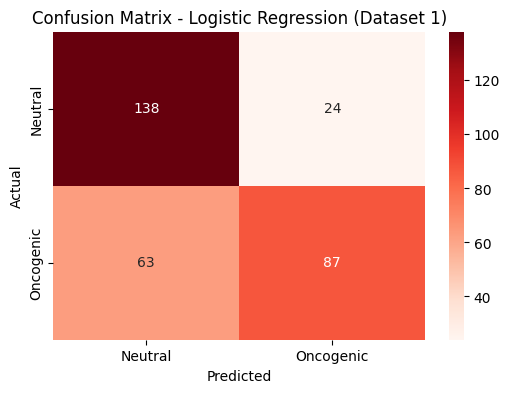

In [20]:
cm = confusion_matrix(y_test_1, y_pred_1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 1)')
plt.show()

### Feature Coeffisients for the Logistic Regression Model

In [21]:
best_model = logistic1.best_estimator_  

coefficients = pd.Series(
    best_model.named_steps['clf'].coef_[0],
    index=best_model.named_steps['preprocessor'].get_feature_names_out()
).sort_values(key=abs, ascending=False) 

print(coefficients)

cat__In_Hotspot_True                                       2.122233
num__gnomAD_AF_log                                        -0.756507
num__Polyphen_Score                                        0.650856
cat__In_Hotspot_False                                     -0.413128
cat__IN_DOMAIN_False                                       0.406031
cat__Variant_Type_SNP                                      0.271765
cat__IN_DOMAIN_True                                       -0.224573
cat__IN_FUNC_SITE_False                                    0.219438
cat__has_gnomAD_AF_True                                   -0.183734
cat__IN_FUNC_SITE_True                                    -0.145068
num__SIFT_Score                                           -0.112225
cat__Variant_Type_TNP                                      0.000000
cat__Variant_Type_DNP                                      0.000000
num__n_protein_domains                                     0.000000
num__n_func_sites                               

## Random Forest Model

### Define CV-strategy, pipeline, and hyperparameters to test 

In [22]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

rf1 = GridSearchCV(
  estimator=pipe_rf1,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

rf2 = GridSearchCV(
  estimator=pipe_rf2,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

rf3 = GridSearchCV(
  estimator=pipe_rf3,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

rf4 = GridSearchCV(
  estimator=pipe_rf4,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

rf5 = GridSearchCV(
  estimator=pipe_rf5,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

### Fit random forest model to all training data 

In [23]:
rf1 = rf1.fit(X_train_1, y_train_1.values.ravel()) 

print(rf1.best_score_)
print(rf1.best_params_)

print(f"The best F1-score (Macro) for dataset 1: {rf1.best_score_}")
print(f"The best hyperparameters: {rf1.best_params_}")

rf2 = rf2.fit(X_train_2, y_train_2.values.ravel()) 

print(rf2.best_score_)
print(rf2.best_params_)

print(f"The best F1-score (Macro) for dataset 2: {rf2.best_score_}")
print(f"The best hyperparameters: {rf2.best_params_}")

rf3 = rf3.fit(X_train_3, y_train_3.values.ravel()) 

print(rf3.best_score_)
print(rf3.best_params_)

print(f"The best F1-score (Macro) for dataset 3: {rf3.best_score_}")
print(f"The best hyperparameters: {rf3.best_params_}")


rf4 = rf4.fit(X_train_4, y_train_4.values.ravel()) 

print(rf4.best_score_)
print(rf4.best_params_)

print(f"The best F1-score (Macro) for dataset 4: {rf4.best_score_}")
print(f"The best hyperparameters: {rf4.best_params_}")

rf5 = rf5.fit(X_train_5, y_train_5.values.ravel()) 

print(rf5.best_score_)
print(rf5.best_params_)

print(f"The best F1-score (Macro) for dataset 5: {rf5.best_score_}")
print(f"The best hyperparameters: {rf5.best_params_}")

0.7643159504689098
{'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 275}
The best F1-score (Macro) for dataset 1: 0.7643159504689098
The best hyperparameters: {'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 275}
0.7390458050359255
{'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 4, 'clf__n_estimators': 225}
The best F1-score (Macro) for dataset 2: 0.7390458050359255
The best hyperparameters: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 4, 'clf__n_estimators': 225}
0.7592811580136628
{'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__

### Evaluate Model Performance (Dataset 5)

Evaluates model performance on dataset 5, since this model performed best on the training data. 

Dataset 5: Full feature set. Impute -1 in rows with missing Polyphen and SIFT scores. 

In [24]:
# Predict classes for dataset 5
y_pred_5 = rf5.predict(X_test_5)

# Predict probabilities
y_probs_5 = rf5.predict_proba(X_test_5)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_5, y_pred_5, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_5, y_pred_5))

Test F1-score (Macro): 0.7666

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.80      0.76       172
           1       0.82      0.74      0.78       210

    accuracy                           0.77       382
   macro avg       0.77      0.77      0.77       382
weighted avg       0.77      0.77      0.77       382



Text(0.5, 1.0, 'Confusion Matrix - Random Forest (Dataset 5)')

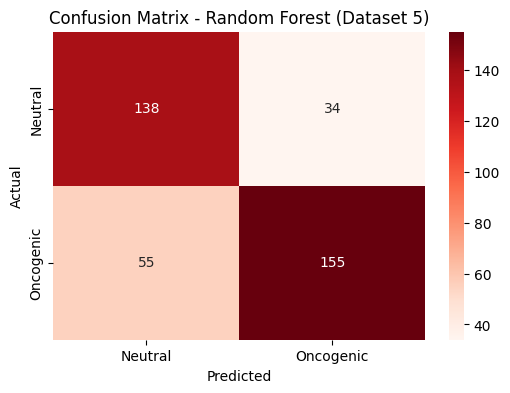

In [25]:
cm = confusion_matrix(y_test_5, y_pred_5)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Dataset 5)')

### Feature importances Random Forest 

In [26]:
# Define the best model 
best_model = rf5.best_estimator_

# Get feature names 
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

num__Polyphen_Score                                                0.172687
num__SIFT_Score                                                    0.144840
cat__hotspot_x_vartype_False_SNP                                   0.092942
num__gnomAD_AF_log                                                 0.081561
cat__In_Hotspot_False                                              0.064693
cat__In_Hotspot_True                                               0.057905
cat__hotspot_x_vartype_True_SNP                                    0.039085
num__n_func_sites                                                  0.029439
cat__has_gnomAD_AF_False                                           0.025093
cat__hotspot_x_vartype_False_DEL                                   0.020529
cat__IN_FUNC_SITE_False                                            0.019613
cat__has_gnomAD_AF_True                                            0.019073
cat__Consequence_missense_variant                                  0.018690
cat__Variant

## XGBoost modeling

### Define CV-strategy, pipeline, and hyperparameters to test 

In [27]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

xgb1 = GridSearchCV(pipe_xgb1, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.02],
                        'clf__max_depth': [3, 5],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1]})

xgb2 = GridSearchCV(pipe_xgb2, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.02],
                        'clf__max_depth': [3, 5],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1]})

xgb3 = GridSearchCV(pipe_xgb3, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.02],
                        'clf__max_depth': [3, 5],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1]})

xgb4 = GridSearchCV(pipe_xgb4, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.02],
                        'clf__max_depth': [3, 5],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1]})

xgb5 = GridSearchCV(pipe_xgb5, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.02],
                        'clf__max_depth': [3, 5],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1]})

In [28]:
xgb1 = xgb1.fit(X_train_1, y_train_1.values.ravel()) 

print(xgb1.best_score_)
print(xgb1.best_params_)

print(f"The best F1-score (Macro) for dataset 1: {xgb1.best_score_}")
print(f"The best hyperparameters: {xgb1.best_params_}")

xgb2 = xgb2.fit(X_train_2, y_train_2.values.ravel()) 

print(xgb2.best_score_)
print(xgb2.best_params_)

print(f"The best F1-score (Macro) for dataset 2: {xgb2.best_score_}")
print(f"The best hyperparameters: {xgb2.best_params_}")

xgb3 = xgb3.fit(X_train_3, y_train_3.values.ravel()) 

print(xgb3.best_score_)
print(xgb3.best_params_)

print(f"The best F1-score (Macro) for dataset 3: {xgb3.best_score_}")
print(f"The best hyperparameters: {xgb3.best_params_}")

xgb4 = xgb4.fit(X_train_4, y_train_4.values.ravel()) 

print(xgb4.best_score_)
print(xgb4.best_params_)

print(f"The best F1-score (Macro) for dataset 4: {xgb4.best_score_}")
print(f"The best hyperparameters: {xgb4.best_params_}")

xgb5 = xgb5.fit(X_train_5, y_train_5.values.ravel()) 

print(xgb5.best_score_)
print(xgb5.best_params_)

print(f"The best F1-score (Macro) for dataset 5: {xgb5.best_score_}")
print(f"The best hyperparameters: {xgb5.best_params_}")

0.7587831241283124
{'clf__colsample_bytree': 0.8, 'clf__gamma': 0.1, 'clf__learning_rate': 0.01, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
The best F1-score (Macro) for dataset 1: 0.7587831241283124
The best hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0.1, 'clf__learning_rate': 0.01, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
0.7283433994823123
{'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.02, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
The best F1-score (Macro) for dataset 2: 0.7283433994823123
The best hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.02, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
0.7554497907949791
{'clf__colsample_bytree': 0.8, 'clf__gamma': 0.1, 'clf__learning_rate': 0.02, 'clf__max_depth': 5, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
The best F1-score (Macro) for datas

### Evaluate Model Performance (Dataset 5)

Evaluates model performance on dataset 5. Dataset 1 performs slightly better on the training data (0.003), but was trained on a smaller sample size. Since dataset 5 retains more data, this will be used for evaluation on test data. 

Dataset 5: Full feature set. Impute -1 in rows with missing Polyphen and SIFT scores. 

In [29]:
# Predict classes for dataset 5
y_pred_5 = xgb5.predict(X_test_5)

# Predict probabilities
y_probs_5 = xgb5.predict_proba(X_test_5)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_5, y_pred_5, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_5, y_pred_5))

Test F1-score (Macro): 0.7598

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       172
           1       0.79      0.78      0.78       210

    accuracy                           0.76       382
   macro avg       0.76      0.76      0.76       382
weighted avg       0.76      0.76      0.76       382



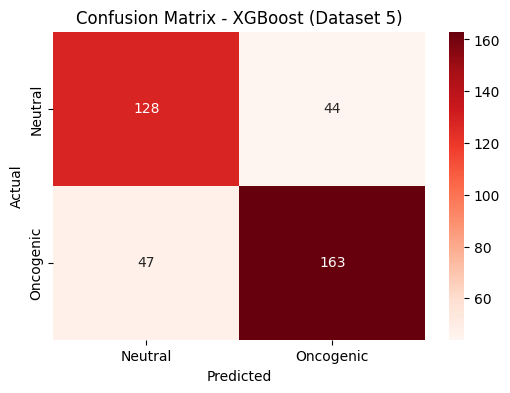

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_5, y_pred_5)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (Dataset 5)')
plt.show()

### Feature Importances XGBoost

In [31]:
# Define the best model 
best_model = xgb5.best_estimator_

# Get feature names 
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

cat__hotspot_x_vartype_False_SNP                                   0.265891
cat__In_Hotspot_True                                               0.100663
cat__In_Hotspot_False                                              0.094432
cat__hotspot_x_vartype_False_DEL                                   0.072442
cat__hotspot_x_vartype_True_SNP                                    0.058617
cat__Variant_Type_SNP                                              0.052942
cat__Variant_Type_DEL                                              0.023682
cat__Consequence_missense_variant                                  0.023408
cat__Consequence_frameshift_variant                                0.018757
num__SIFT_Score                                                    0.018245
cat__hotspot_x_vartype_False_TNP                                   0.016698
cat__Consequence_protein_altering_variant                          0.016138
cat__has_gnomAD_AF_False                                           0.014835
cat__IN_DOMA

## Run Best Model (xgb5) on Selected Top Oncogenic Genes

### TP53 dataset 

Define the data: 

In [33]:
X_train_TP53 = X_train[X_train["Hugo_Symbol"] == 'TP53']
X_test_TP53 = X_test[X_test["Hugo_Symbol"] == 'TP53']

impute_cols = ['SIFT_Score', 'Polyphen_Score']
X_train_TP53[impute_cols] = X_train_TP53[impute_cols].fillna(-1)
X_test_TP53[impute_cols] = X_test_TP53[impute_cols].fillna(-1)

X_train_TP53 = X_train_TP53.drop(columns="Hugo_Symbol")
X_test_TP53 = X_test_TP53.drop(columns="Hugo_Symbol")

# Filter y to match TP53 indices
y_train_TP53 = y_train.loc[X_train_TP53.index]
y_test_TP53 = y_test.loc[X_test_TP53.index]

Fit model to data: 

In [34]:
xgb5_TP53 = xgb5.fit(X_train_TP53, y_train_TP53.values.ravel()) 

print(xgb5_TP53.best_score_)
print(xgb5_TP53.best_params_)

print(f"The best F1-score (Macro) for the TP53 dataset: {xgb5_TP53.best_score_}")
print(f"The best hyperparameters: {xgb5_TP53.best_params_}")

0.7666666666666667
{'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
The best F1-score (Macro) for the TP53 dataset: 0.7666666666666667
The best hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}


Predict classes and make classification report: 

In [35]:
# Predict classes for the TP53 dataset
y_pred_TP53 = xgb5_TP53.predict(X_test_TP53)

# Predict probabilities
y_probs_TP53 = xgb5_TP53.predict_proba(X_test_TP53)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_TP53, y_pred_TP53, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_TP53, y_pred_TP53))

Test F1-score (Macro): 0.2667

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.80      0.53         5
           1       0.00      0.00      0.00         6

    accuracy                           0.36        11
   macro avg       0.20      0.40      0.27        11
weighted avg       0.18      0.36      0.24        11



Create confusion matrix: 

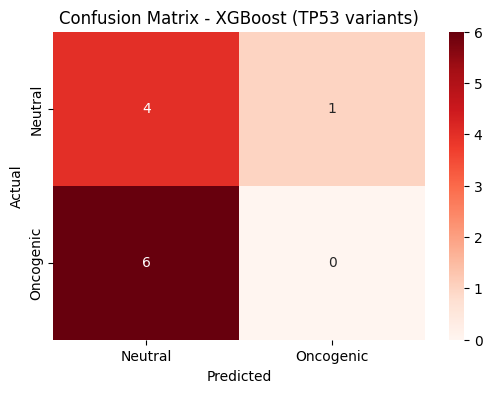

In [36]:
cm = confusion_matrix(y_test_TP53, y_pred_TP53)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (TP53 variants)')
plt.show()

Find feature importances: 

In [37]:
# Define the best model 
best_model_TP53 = xgb5_TP53.best_estimator_

# Get feature names 
feature_names = best_model_TP53.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model_TP53.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

num__Polyphen_Score                  0.515030
num__SIFT_Score                      0.374435
num__hotspot_and_func                0.110535
num__gnomAD_AF_log                   0.000000
num__missing_Polyphen                0.000000
num__missing_SIFT                    0.000000
num__n_func_sites                    0.000000
num__n_protein_domains               0.000000
cat__Variant_Type_SNP                0.000000
cat__has_gnomAD_AF_False             0.000000
cat__has_gnomAD_AF_True              0.000000
cat__Consequence_missense_variant    0.000000
cat__In_Hotspot_False                0.000000
cat__In_Hotspot_True                 0.000000
cat__IN_DOMAIN_False                 0.000000
cat__IN_DOMAIN_True                  0.000000
cat__IN_FUNC_SITE_True               0.000000
cat__hotspot_x_vartype_False_SNP     0.000000
cat__hotspot_x_vartype_True_SNP      0.000000
dtype: float32


### EGFR dataset

Define the data: 

In [38]:
X_train_EGFR = X_train[X_train["Hugo_Symbol"] == 'EGFR']
X_test_EGFR = X_test[X_test["Hugo_Symbol"] == 'EGFR']

impute_cols = ['SIFT_Score', 'Polyphen_Score']
X_train_EGFR[impute_cols] = X_train_EGFR[impute_cols].fillna(-1)
X_test_EGFR[impute_cols] = X_test_EGFR[impute_cols].fillna(-1)

X_train_EGFR = X_train_EGFR.drop(columns="Hugo_Symbol")
X_test_EGFR = X_test_EGFR.drop(columns="Hugo_Symbol")

# Filter y to match EGFR indices
y_train_EGFR = y_train.loc[X_train_EGFR.index]
y_test_EGFR = y_test.loc[X_test_EGFR.index]

Fit model to data: 

In [39]:
xgb5_EGFR = xgb5.fit(X_train_EGFR, y_train_EGFR.values.ravel()) 

print(xgb5_EGFR.best_score_)
print(xgb5_EGFR.best_params_)

print(f"The best F1-score (Macro) for the EGFR dataset: {xgb5_EGFR.best_score_}")
print(f"The best hyperparameters: {xgb5_EGFR.best_params_}")

0.8130718954248366
{'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
The best F1-score (Macro) for the EGFR dataset: 0.8130718954248366
The best hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}


Predict classes and make classification report: 

In [40]:
# Predict classes for the EGFR dataset
y_pred_EGFR = xgb5_EGFR.predict(X_test_EGFR)

# Predict probabilities
y_probs_EGFR = xgb5_EGFR.predict_proba(X_test_EGFR)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_EGFR, y_pred_EGFR, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_EGFR, y_pred_EGFR))

Test F1-score (Macro): 0.6703

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.71      0.83      0.77         6

    accuracy                           0.70        10
   macro avg       0.69      0.67      0.67        10
weighted avg       0.70      0.70      0.69        10



Create confusion matrix:

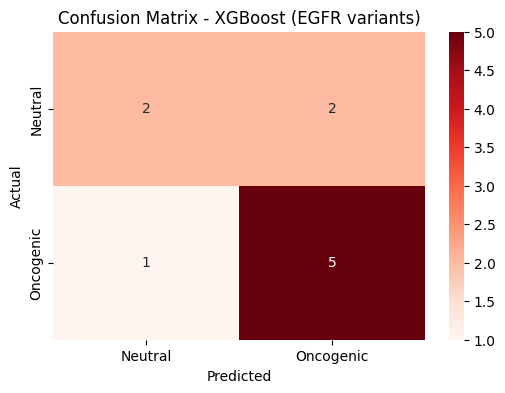

In [41]:
cm = confusion_matrix(y_test_EGFR, y_pred_EGFR)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (EGFR variants)')
plt.show()

Find feature importances: 

In [42]:
# Define the best model 
best_model_EGFR = xgb5_EGFR.best_estimator_

# Get feature names 
feature_names = best_model_EGFR.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model_EGFR.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

cat__hotspot_x_vartype_False_SNP                           0.308092
cat__Variant_Type_SNP                                      0.155971
cat__Consequence_missense_variant                          0.149139
num__hotspot_and_func                                      0.104016
cat__In_Hotspot_True                                       0.067776
cat__In_Hotspot_False                                      0.063396
num__SIFT_Score                                            0.042627
num__n_func_sites                                          0.039908
num__n_protein_domains                                     0.030777
num__Polyphen_Score                                        0.018992
cat__has_gnomAD_AF_False                                   0.012633
num__missing_Polyphen                                      0.004688
num__gnomAD_AF_log                                         0.001984
cat__Variant_Type_DNP                                      0.000000
cat__Variant_Type_INS                           

### BRAF dataset

Define the data: 

In [43]:
X_train_BRAF = X_train[X_train["Hugo_Symbol"] == 'BRAF']
X_test_BRAF = X_test[X_test["Hugo_Symbol"] == 'BRAF']

X_train_BRAF[impute_cols] = X_train_BRAF[impute_cols].fillna(-1)
X_test_BRAF[impute_cols] = X_test_BRAF[impute_cols].fillna(-1)

X_train_BRAF = X_train_BRAF.drop(columns="Hugo_Symbol")
X_test_BRAF = X_test_BRAF.drop(columns="Hugo_Symbol")

# Filter to match BRAF indices 
y_train_BRAF = y_train.loc[X_train_BRAF.index]
y_test_BRAF = y_test.loc[X_test_BRAF.index]

Fit model to data: 

In [44]:
xgb5_BRAF = xgb5.fit(X_train_BRAF, y_train_BRAF.values.ravel()) 

print(xgb5_BRAF.best_score_)
print(xgb5_BRAF.best_params_)

print(f"The best F1-score (Macro) for the BRAF dataset: {xgb5_BRAF.best_score_}")
print(f"The best hyperparameters: {xgb5_BRAF.best_params_}")

0.7711111111111111
{'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
The best F1-score (Macro) for the BRAF dataset: 0.7711111111111111
The best hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}


Predict classes and make classification report:

In [45]:
# Predict classes for the BRAF dataset
y_pred_BRAF = xgb5_BRAF.predict(X_test_BRAF)

# Predict probabilities
y_probs_BRAF = xgb5_BRAF.predict_proba(X_test_BRAF)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_BRAF, y_pred_BRAF, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_BRAF, y_pred_BRAF))

Test F1-score (Macro): 0.9150

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.89      0.94         9

    accuracy                           0.92        13
   macro avg       0.90      0.94      0.92        13
weighted avg       0.94      0.92      0.93        13



Create confusion matrix: 

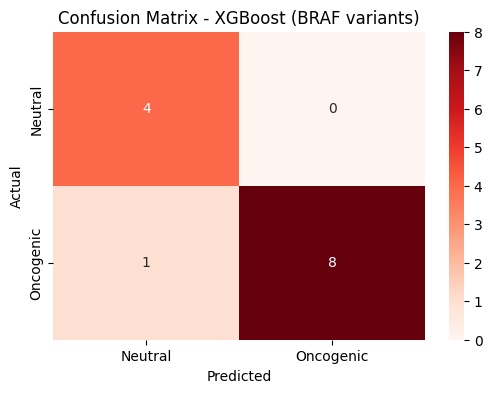

In [46]:
cm = confusion_matrix(y_test_BRAF, y_pred_BRAF)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (BRAF variants)')
plt.show()

Find feature importances: 

In [47]:
# Define the best model 
best_model_BRAF = xgb5_BRAF.best_estimator_

# Get feature names 
feature_names = best_model_BRAF.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model_BRAF.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

cat__hotspot_x_vartype_False_SNP                           0.304122
cat__In_Hotspot_True                                       0.248631
cat__In_Hotspot_False                                      0.165731
num__SIFT_Score                                            0.088216
num__Polyphen_Score                                        0.057398
cat__Consequence_missense_variant                          0.047963
cat__hotspot_x_vartype_True_SNP                            0.031981
num__n_protein_domains                                     0.027859
num__n_func_sites                                          0.015886
cat__IN_FUNC_SITE_False                                    0.012212
cat__Variant_Type_DEL                                      0.000000
cat__Variant_Type_DNP                                      0.000000
num__hotspot_and_func                                      0.000000
num__gnomAD_AF_log                                         0.000000
num__missing_SIFT                               

### ERBB2 dataset 

Define the data: 

In [48]:
X_train_ERBB2 = X_train[X_train["Hugo_Symbol"] == 'ERBB2']
X_test_ERBB2 = X_test[X_test["Hugo_Symbol"] == 'ERBB2']

X_train_ERBB2[impute_cols] = X_train_ERBB2[impute_cols].fillna(-1)
X_test_ERBB2[impute_cols] = X_test_ERBB2[impute_cols].fillna(-1)

X_train_ERBB2 = X_train_ERBB2.drop(columns="Hugo_Symbol")
X_test_ERBB2 = X_test_ERBB2.drop(columns="Hugo_Symbol")

# Filter to match ERBB2 indices 
y_train_ERBB2 = y_train.loc[X_train_ERBB2.index]
y_test_ERBB2 = y_test.loc[X_test_ERBB2.index]

Fit model to data: 

In [49]:
xgb5_ERBB2 = xgb5.fit(X_train_ERBB2, y_train_ERBB2.values.ravel()) 

print(xgb5_ERBB2.best_score_)
print(xgb5_ERBB2.best_params_)

print(f"The best F1-score (Macro) for the ERBB2 dataset: {xgb5_ERBB2.best_score_}")
print(f"The best hyperparameters: {xgb5_ERBB2.best_params_}")

0.8621212121212121
{'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
The best F1-score (Macro) for the ERBB2 dataset: 0.8621212121212121
The best hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}


Predict classes and make classification report: 

In [50]:
# Predict classes for the ERBB2 dataset
y_pred_ERBB2 = xgb5_ERBB2.predict(X_test_ERBB2)

# Predict probabilities
y_probs_ERBB2 = xgb5_ERBB2.predict_proba(X_test_ERBB2)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_ERBB2, y_pred_ERBB2, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_ERBB2, y_pred_ERBB2))

Test F1-score (Macro): 0.8571

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.86      0.86      0.86         7

    accuracy                           0.86        14
   macro avg       0.86      0.86      0.86        14
weighted avg       0.86      0.86      0.86        14



Create confusion matrix:

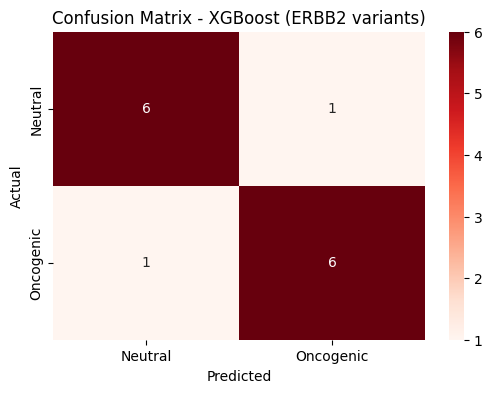

In [51]:
cm = confusion_matrix(y_test_ERBB2, y_pred_ERBB2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (ERBB2 variants)')
plt.show()

Find feature importances: 

In [52]:
# Define the best model 
best_model_ERBB2 = xgb5_ERBB2.best_estimator_

# Get feature names 
feature_names = best_model_ERBB2.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model_ERBB2.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

cat__hotspot_x_vartype_False_SNP                           0.273529
num__gnomAD_AF_log                                         0.143103
cat__Variant_Type_SNP                                      0.129659
cat__has_gnomAD_AF_False                                   0.116518
num__hotspot_and_func                                      0.116503
cat__In_Hotspot_False                                      0.099092
cat__Consequence_protein_altering_variant                  0.032046
cat__Consequence_missense_variant                          0.030903
num__Polyphen_Score                                        0.028053
num__SIFT_Score                                            0.026235
cat__hotspot_x_vartype_True_SNP                            0.004358
num__n_func_sites                                          0.000000
num__missing_SIFT                                          0.000000
num__n_protein_domains                                     0.000000
num__missing_Polyphen                           